# **Machine Learning Development Lifecycle Methodology**

### **MLDLC FlowCharts**

![alt text](mldlc_steps.jpg)

### **Importing Libraries**

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from mlxtend.plotting import plot_decision_regions
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

### **Load Dataset**

In [2]:
df = pd.read_csv("placement.csv")

In [3]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.2 KB


In [5]:
df.shape

(100, 4)

First column (index) dropped

In [6]:
df = df.iloc[:, 1:]

In [7]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


### **Steps (Sahi Order - Data Leakage se bacho):**
0. Data Load + EDA + Feature Selection
1. Input/Output columns extract karo
2. Train-Test Split  (PEHLE split)
3. Scale karo        (BAAD MEIN scale - sirf train pe fit)
4. Model train karo
5. Evaluate karo
6. Model + Scaler dono save karo (Deploy ke liye)

Step 0: EDA

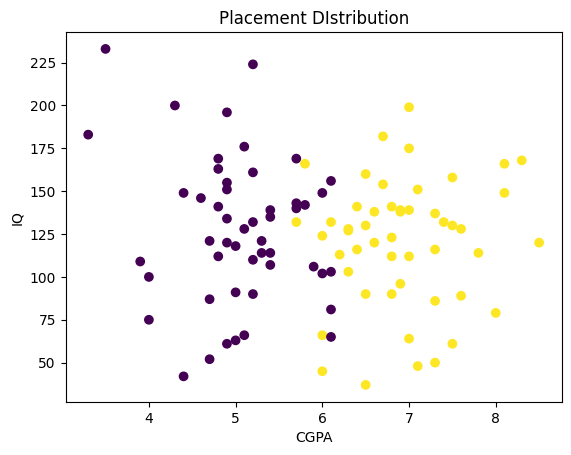

In [8]:
plt.scatter(df['cgpa'], df['iq'], c=df['placement'])
plt.xlabel('CGPA')
plt.ylabel('IQ')
plt.title('Placement DIstribution')
plt.show()

Step 1: Input/Output columns

In [9]:
X = df.iloc[:, 0:2]
y = df.iloc[:, -1]

print("X shape:", X.shape)
print("Y shape:", y.shape)

X shape: (100, 2)
Y shape: (100,)


Step 2: Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (80, 2)
Test size: (20, 2)


Step 3: Scaling

In [ ]:
X_train_np = X_train.values   
X_test_np  = X_test.values

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_np) # fit + transform
X_test_scaled = scaler.transform(X_test_np) # Only transform (Not fit)

Step 4: Model training

In [13]:
clf = LogisticRegression()
clf.fit(X_train_scaled, y_train)

LogisticRegression()

Step 5: Evaluate

In [14]:
y_pred = clf.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.85


Decision boundary plot

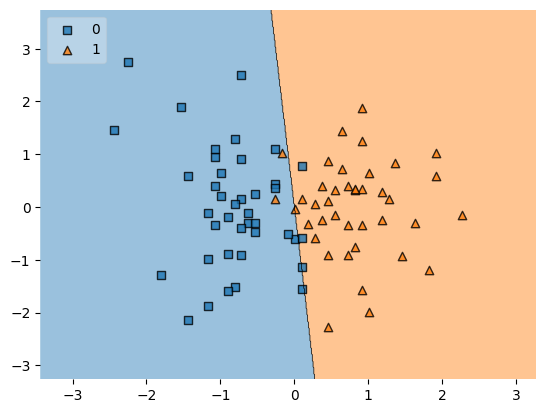

In [ ]:
plot_decision_regions(np.array(X_train_scaled), y_train.values, clf=clf, legend=2)
plt.show()

Step 6: Model + Scaler Saving Model

In [17]:
pickle.dump(scaler, open('models/scaler.pkl', 'wb'))
pickle.dump(clf, open('models/model.pkl', 'wb'))

print("Model and Scaler was saved!")

Model and Scaler was saved!


### **DEPLOYMENT PIPELINE - Model Load & Predict**

Step 1: Load Two files  (scaler + model)

In [18]:
loaded_scaler = pickle.load(open('models/scaler.pkl', 'rb'))
loaded_model = pickle.load(open('models/model.pkl', 'rb'))

print("Scaler and Model loaded!")

Scaler and Model loaded!


Step 2: Make new data (In real life, it will come from the user.)

Example: CGPA=8.5, IQ=120


In [20]:
new_student = pd.DataFrame([[8.5, 120]], columns=['cgpa', 'iq'])
print("New student data:", new_student)

New student data:    cgpa   iq
0   8.5  120


Step 3: Scale it using a scaler (IMPORTANT - the format must match training).

In [22]:
new_student_scaled = loaded_scaler.transform(new_student.values)
print("Scaled data", new_student_scaled)

Scaled data [[ 2.27463902 -0.14588782]]


Step 4: Make a prediction.

In [23]:
prediction = loaded_model.predict(new_student_scaled)
print("Prediction (0=No, 1=Yes):", prediction)

Prediction (0=No, 1=Yes): [1]


Step 5: Also check the probability (confidence score).

In [24]:
probability = loaded_model.predict_proba(new_student_scaled)

print("No Placement probability :", round(probability[0][0] * 100, 2), "%")
print("Yes Placement probability :", round(probability[0][1] * 100, 2), "%")

No Placement probability : 0.07 %
Yes Placement probability : 99.93 %


Step 6: Human-readable output

In [25]:
if prediction[0] == 1:
    print(f"✅ Placement will happen! Confidence: {round(probability[0][1]*100, 2)}%")
else:
    print(f"❌ Placement will not happen! Confidence: {round(probability[0][0]*100, 2)}%")

✅ Placement will happen! Confidence: 99.93%


Bonus: Predict multiple students at the same time.

In [30]:
multiple_students = pd.DataFrame([
    [8.5, 120], # Student 1
    [5.2, 90],  # Student 2
    [7.8, 110], # Student 3
    [4.1, 85],  # Student 4
], columns=['cgpa', 'iq'])

# Scale it.
multiple_scaled = loaded_scaler.transform(multiple_students.values)

# Predict it.
predictions = loaded_model.predict(multiple_scaled)
probabilities = loaded_model.predict_proba(multiple_scaled)

print("\n--- Multiple Students Results ---\n")
for i, (pred, prob) in enumerate(zip(predictions, probabilities)):
    status = "✅ Placed" if pred == 1 else "❌ Not Placed"
    confidence = prob[1] if pred == 1 else prob[0]
    print(f"Student {i+1} | CGPA: {multiple_students.iloc[i, 0]} "
          f"| IQ: {multiple_students.iloc[i, 1]} "
          f"| {status} | Confidence: {round(confidence*100, 2)}%")


--- Multiple Students Results ---

Student 1 | CGPA: 8.5 | IQ: 120 | ✅ Placed | Confidence: 99.93%
Student 2 | CGPA: 5.2 | IQ: 90 | ❌ Not Placed | Confidence: 92.66%
Student 3 | CGPA: 7.8 | IQ: 110 | ✅ Placed | Confidence: 99.4%
Student 4 | CGPA: 4.1 | IQ: 85 | ❌ Not Placed | Confidence: 99.68%
